In [1]:
import scanpy as sc
import os
import scanpy as sc
import pandas as pd
import numpy as np
os.getcwd()

'/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/Infer_plaque_type/0523_no_Basophil'

#### with other unknown
整体流程

```text
第一步：生成 X_basic_celltype_proportion.csv 和 y_sample_label_numeric.csv
        ↓
中间这一步：生成 X_pseudobulk_marker.csv
        ↓
再拼接生成 X_combined_basic_plus_pseudobulk.csv
        ↓
训练验证 LogisticRegression
        ↓
生成 unknown 特征 / 预测 unknown

##### prepare input

In [2]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse

# ========================= 参数 =========================
H5AD_PATH = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_allhuman/scPoli_concat_level3_marker_all_metadata.h5ad"
OUT_DIR = "./output/"
os.makedirs(OUT_DIR, exist_ok=True)

SAMPLE_COL = "sample"
# CELLTYPE_COL = "cell_type_level1"
CELLTYPE_COL = "cell_type_level1_corrected"##应该用cell_type_level1_corrected
LABEL_RAW_COL = "Plaque_type"
LABEL_COL = "Plaque_type_clean"

TRAIN_X_BASIC_PATH = f"{OUT_DIR}/X_basic_celltype_proportion.csv"
TRAIN_X_PB_PATH = f"{OUT_DIR}/X_pseudobulk_marker.csv"
TRAIN_X_COMBINED_PATH = f"{OUT_DIR}/X_combined_basic_plus_pseudobulk.csv"
Y_LABEL_PATH = f"{OUT_DIR}/y_sample_label.csv"
Y_NUM_PATH = f"{OUT_DIR}/y_sample_label_numeric.csv"

OUT_X_BASIC_UNKNOWN = f"{OUT_DIR}/X_basic_unknown_celltype_proportion.csv"
OUT_X_PB_UNKNOWN = f"{OUT_DIR}/X_pseudobulk_marker_unknown.csv"
OUT_X_UNKNOWN_COMBINED = f"{OUT_DIR}/X_unknown_combined_basic_plus_pseudobulk.csv"

marker_dict = {
    "Macrophage": ["C1QA", "C1QB", "CD68", "AIF1", "LGALS3", "CD163"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "TAGLN", "CALD1", "NOTCH3", "PDGFRB"],
    "Endothelial cell": ["PECAM1", "VWF", "CLDN5", "CD34", "PLVAP", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "THY1"]
}

def get_mean_expression(sub_adata, genes):
    if len(genes) == 0:
        return pd.Series(dtype=float)
    sub = sub_adata[:, genes]
    X = sub.X
    mean_expr = np.asarray(X.mean(axis=0)).ravel() if sparse.issparse(X) else np.asarray(X.mean(axis=0)).ravel()
    return pd.Series(mean_expr, index=genes)

def build_pseudobulk_features(adata_in, marker_dict, sample_col, celltype_col):
    all_genes = set(adata_in.var_names)
    filtered_marker_dict, missing_marker_report = {}, {}
    for ct, genes in marker_dict.items():
        present = [g for g in genes if g in all_genes]
        missing = [g for g in genes if g not in all_genes]
        filtered_marker_dict[ct] = present
        missing_marker_report[ct] = missing
    print("\n===== marker presence check =====")
    for ct in marker_dict:
        print(f"{ct}:")
        print("  present:", filtered_marker_dict[ct])
        print("  missing:", missing_marker_report[ct])
    filtered_marker_dict = {ct: genes for ct, genes in filtered_marker_dict.items() if len(genes) > 0}
    all_celltypes = set(adata_in.obs[celltype_col].astype(str).unique())
    print("\n===== cell types in adata =====")
    print(sorted(list(all_celltypes))[:50])
    valid_celltypes = [ct for ct in filtered_marker_dict if ct in all_celltypes]
    invalid_celltypes = [ct for ct in filtered_marker_dict if ct not in all_celltypes]
    if len(invalid_celltypes) > 0:
        print("\n这些 marker_dict 里的 cell type 不在 adata.obs 里，请检查命名：")
        print(invalid_celltypes)
    filtered_marker_dict = {ct: filtered_marker_dict[ct] for ct in valid_celltypes}
    if len(filtered_marker_dict) == 0:
        raise ValueError("没有任何有效的 cell type + marker 组合。")
    feature_rows = []
    sample_ids = adata_in.obs[sample_col].astype(str).unique().tolist()
    for sample_id in sample_ids:
        sample_mask = adata_in.obs[sample_col].astype(str) == str(sample_id)
        adata_sample = adata_in[sample_mask].copy()
        row_dict = {"sample": sample_id}
        for ct, genes in filtered_marker_dict.items():
            ct_mask = adata_sample.obs[celltype_col].astype(str) == ct
            n_cells = int(ct_mask.sum())
            if n_cells == 0:
                for g in genes:
                    row_dict[f"pb__{ct}__{g}"] = 0.0
                row_dict[f"pb_ncells__{ct}"] = 0
                continue
            adata_sub = adata_sample[ct_mask].copy()
            mean_expr = get_mean_expression(adata_sub, genes)
            for g in genes:
                row_dict[f"pb__{ct}__{g}"] = float(mean_expr[g])
            row_dict[f"pb_ncells__{ct}"] = n_cells
        feature_rows.append(row_dict)
    X_pb = pd.DataFrame(feature_rows).set_index("sample").sort_index()
    return X_pb

# ========================= 1. 读取和预处理 h5ad =========================
print("Reading h5ad...")
adata = sc.read_h5ad(H5AD_PATH)
adata = adata[adata.obs[CELLTYPE_COL] != "unknown"].copy()
adata.var["original_feature_id"] = adata.var_names.astype(str)
adata.var_names = adata.var["original_gene_names"].astype(str)
adata.var_names_make_unique()
adata.obs[LABEL_COL] = adata.obs[LABEL_RAW_COL].astype(str).str.strip().str.lower()

adata.obs[LABEL_COL] = adata.obs[LABEL_COL].replace({
    "nan": "unknown",
    "na": "unknown",
    "none": "unknown",
    "": "unknown",
    "unknown": "unknown",
    "Unknown": "unknown",
})
adata.obs[LABEL_COL] = adata.obs[LABEL_COL].fillna("unknown")

required_cols = [SAMPLE_COL, CELLTYPE_COL, LABEL_COL]
missing_cols = [c for c in required_cols if c not in adata.obs.columns]
if len(missing_cols) > 0:
    raise ValueError(f"adata.obs 缺少这些列: {missing_cols}")

print("adata shape after filtering unknown cell type:", adata.shape)
print("sample label distribution:")
print(adata.obs[LABEL_COL].value_counts(dropna=False))

# ========================= 2. 生成训练集 X_basic 和 y =========================
print("\nBuilding training X_basic and y...")
obs = adata.obs[[SAMPLE_COL, CELLTYPE_COL, LABEL_COL]].copy()
obs = obs.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])
train_obs = obs[obs[LABEL_COL].isin(["stable", "unstable"])].copy()

print("训练细胞数:", train_obs.shape[0])
print("训练标签分布:")
print(train_obs[LABEL_COL].value_counts())

cell_count = pd.crosstab(train_obs[SAMPLE_COL], train_obs[CELLTYPE_COL])
cell_prop = cell_count.div(cell_count.sum(axis=1), axis=0)
cell_prop.columns = [f"prop__{c}" for c in cell_prop.columns]

sample_label = train_obs[[SAMPLE_COL, LABEL_COL]].drop_duplicates().groupby(SAMPLE_COL, observed=True)[LABEL_COL].agg(lambda x: x.iloc[0] if len(set(x)) == 1 else "conflict")
conflict_samples = sample_label[sample_label == "conflict"].index.tolist()
if len(conflict_samples) > 0:
    print("仍然冲突的 sample:", conflict_samples[:20])
    raise ValueError("还有 sample 存在多个标签，请进一步检查。")

sample_label = sample_label.rename("label")
common_samples = cell_prop.index.intersection(sample_label.index)
X_basic = cell_prop.loc[common_samples].copy().sort_index()
y = sample_label.loc[common_samples].copy().sort_index()
y_num = y.map({"stable": 0, "unstable": 1})

print("X_basic shape:", X_basic.shape)
print("y shape:", y_num.shape)
print("y label counts:")
print(y.value_counts())

X_basic.to_csv(TRAIN_X_BASIC_PATH)
y.to_csv(Y_LABEL_PATH, header=True)
y_num.to_csv(Y_NUM_PATH, header=True)
print(f"Saved: {TRAIN_X_BASIC_PATH}")
print(f"Saved: {Y_LABEL_PATH}")
print(f"Saved: {Y_NUM_PATH}")

# ========================= 3. 生成训练集 X_pseudobulk 和 X_combined =========================
print("\nBuilding training X_pseudobulk...")
adata_train = adata[adata.obs[LABEL_COL].isin(["stable", "unstable"])].copy()
X_pb = build_pseudobulk_features(adata_train, marker_dict, SAMPLE_COL, CELLTYPE_COL)
X_pb.to_csv(TRAIN_X_PB_PATH)
print("X_pb shape:", X_pb.shape)
print(f"Saved: {TRAIN_X_PB_PATH}")

common_samples = X_basic.index.intersection(X_pb.index)
X_combined = pd.concat([X_basic.loc[common_samples], X_pb.loc[common_samples]], axis=1)
X_combined.to_csv(TRAIN_X_COMBINED_PATH)
print("X_combined shape:", X_combined.shape)
print(f"Saved: {TRAIN_X_COMBINED_PATH}")

# ========================= 4. 生成 unknown 样本 X_basic_unknown =========================
print("\nBuilding unknown features...")
adata_unknown = adata[adata.obs[LABEL_COL].isin(["unknown"])].copy()
print("adata_unknown shape:", adata_unknown.shape)
print("unknown label counts:")
print(adata_unknown.obs[LABEL_COL].value_counts())

if adata_unknown.n_obs == 0:
    raise ValueError("没有找到标签为 unknown 的样本。")

obs_unknown = adata_unknown.obs[[SAMPLE_COL, CELLTYPE_COL, LABEL_COL]].copy()
obs_unknown = obs_unknown.dropna(subset=[SAMPLE_COL, CELLTYPE_COL])
cell_count_unknown = pd.crosstab(obs_unknown[SAMPLE_COL], obs_unknown[CELLTYPE_COL])
cell_prop_unknown = cell_count_unknown.div(cell_count_unknown.sum(axis=1), axis=0)
cell_prop_unknown.columns = [f"prop__{c}" for c in cell_prop_unknown.columns]

X_basic_unknown = cell_prop_unknown.copy()
X_basic_unknown = X_basic_unknown.reindex(columns=X_basic.columns, fill_value=0)
X_basic_unknown.to_csv(OUT_X_BASIC_UNKNOWN)
print("X_basic_unknown shape:", X_basic_unknown.shape)
print(f"Saved: {OUT_X_BASIC_UNKNOWN}")

# ========================= 5. 生成 unknown 样本 X_pseudobulk 和 X_unknown_combined =========================
print("\nBuilding unknown X_pseudobulk...")
X_pb_unknown = build_pseudobulk_features(adata_unknown, marker_dict, SAMPLE_COL, CELLTYPE_COL)
X_pb_unknown = X_pb_unknown.reindex(columns=X_pb.columns, fill_value=0)
X_pb_unknown.to_csv(OUT_X_PB_UNKNOWN)
print("X_pb_unknown shape:", X_pb_unknown.shape)
print(f"Saved: {OUT_X_PB_UNKNOWN}")

common_unknown_samples = X_basic_unknown.index.intersection(X_pb_unknown.index)
X_unknown_combined = pd.concat([X_basic_unknown.loc[common_unknown_samples], X_pb_unknown.loc[common_unknown_samples]], axis=1)
X_unknown_combined = X_unknown_combined.reindex(columns=X_combined.columns, fill_value=0)
X_unknown_combined.to_csv(OUT_X_UNKNOWN_COMBINED)
print("X_unknown_combined shape:", X_unknown_combined.shape)
print(f"Saved: {OUT_X_UNKNOWN_COMBINED}")

print("\nDone.")

Reading h5ad...
adata shape after filtering unknown cell type: (1004247, 28868)
sample label distribution:
Plaque_type_clean
unknown     790610
unstable    152880
stable       60757
Name: count, dtype: int64

Building training X_basic and y...
训练细胞数: 213637
训练标签分布:
Plaque_type_clean
unstable    152880
stable       60757
Name: count, dtype: int64
X_basic shape: (23, 13)
y shape: (23,)
y label counts:
label
unstable    16
stable       7
Name: count, dtype: int64
Saved: ./output//X_basic_celltype_proportion.csv
Saved: ./output//y_sample_label.csv
Saved: ./output//y_sample_label_numeric.csv

Building training X_pseudobulk...

===== marker presence check =====
Macrophage:
  present: ['C1QA', 'C1QB', 'CD68', 'AIF1', 'LGALS3', 'CD163']
  missing: []
Smooth muscle cell:
  present: ['ACTA2', 'MYH11', 'TAGLN', 'CALD1', 'NOTCH3', 'PDGFRB']
  missing: []
Endothelial cell:
  present: ['PECAM1', 'VWF', 'CLDN5', 'CD34', 'PLVAP', 'EDN1']
  missing: []
Fibroblast:
  present: ['LUM', 'DCN', 'COL1A1', 'C

##### train

In [ ]:
# 这个是把有标签的数据全部拿来训练 没有标签的数据拿来预测-----没办法看预测准确性
# import pandas as pd
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

# # 训练集
# X_train = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
# y_train = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# # 训练最终模型
# final_model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("clf", LogisticRegression(
#         penalty="l2",
#         C=1.0,
#         class_weight="balanced",
#         max_iter=1000,
#         random_state=42
#     ))
# ])

# final_model.fit(X_train, y_train)

# # unknown 特征
# X_unknown = pd.read_csv("./output/X_unknown_combined_basic_plus_pseudobulk.csv", index_col=0)
# X_unknown = X_unknown.reindex(columns=X_train.columns, fill_value=0)

# # 预测 unstable 概率
# prob_unstable = final_model.predict_proba(X_unknown)[:, 1]

# result = pd.DataFrame({
#     "sample_id": X_unknown.index,
#     "prob_unstable": prob_unstable
# })

# # 按 0.6 阈值
# result["pred_label_0.6"] = (result["prob_unstable"] >= 0.6).astype(int)
# result["pred_label_0.6"] = result["pred_label_0.6"].map({
#     1: "unstable",
#     0: "non-unstable"
# })

# # 三档解释
# def assign_3class(p):
#     if p >= 0.8:
#         return "high-confidence unstable"
#     elif p >= 0.6:
#         return "unstable-like"
#     else:
#         return "non-unstable"

# result["pred_3class"] = result["prob_unstable"].apply(assign_3class)

# print(result.sort_values("prob_unstable", ascending=False))
# result.to_csv("./output/unknown_prediction_final_lr.csv", index=False)

             sample_id  prob_unstable pred_label_0.6               pred_3class
7                AAA_9       0.997424       unstable  high-confidence unstable
21              TAA_Z3       0.996855       unstable  high-confidence unstable
20              TAA_Z1       0.994187       unstable  high-confidence unstable
22        TAD2_Z2_3LIB       0.993712       unstable  high-confidence unstable
24      TAD_AD1_2_3LIB       0.993119       unstable  high-confidence unstable
2           AAA_1_3LIB       0.987794       unstable  high-confidence unstable
3           AAA_2_3LIB       0.985235       unstable  high-confidence unstable
23        TAD2_Z3_3LIB       0.973533       unstable  high-confidence unstable
5           AAA_4_3LIB       0.962783       unstable  high-confidence unstable
6                AAA_8       0.844989       unstable  high-confidence unstable
1                3_AAA       0.832300       unstable  high-confidence unstable
0                 1_JD       0.789074       unstable

#### 折线图-5次求平均

In [3]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 5

# unstable 判定阈值
threshold = 0.6

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output/lr_train_size_cv_summary.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output/lr_train_size_cv_all_fold_predictions.csv",
    index=False
)

print("\nSaved:")
print("./output/lr_train_size_cv_summary.csv")
print("./output/lr_train_size_cv_all_fold_predictions.csv")

X shape: (23, 40)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.9000, AUC = 1.0000, F1 = 0.9333
Confusion matrix:
[[2 1]
 [0 7]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.7143, F1 = 0.8000
Confusion matrix:
[[1 2]
 [1 6]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.9048, F1 = 0.8333
Confusion matrix:
[[3 0]
 [2 5]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 1.0000, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.9048, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Training size = 65%, Holdout size = 35%

Fold 1
n_train = 14, n_test = 9
Accuracy = 0.8889, AUC = 1.0000, F1 = 0.9231
Confusion matrix:
[[2 1]
 [0 6]]

Fold 2
n_train = 14, n_test = 9
Accuracy = 0.6667, AUC = 0.6667, F1 = 0.7692
Confusion matrix:
[[1 2]
 [1 5]]

Fold 3
n_train = 14, n_test = 9
Accuracy = 0.8889, AU

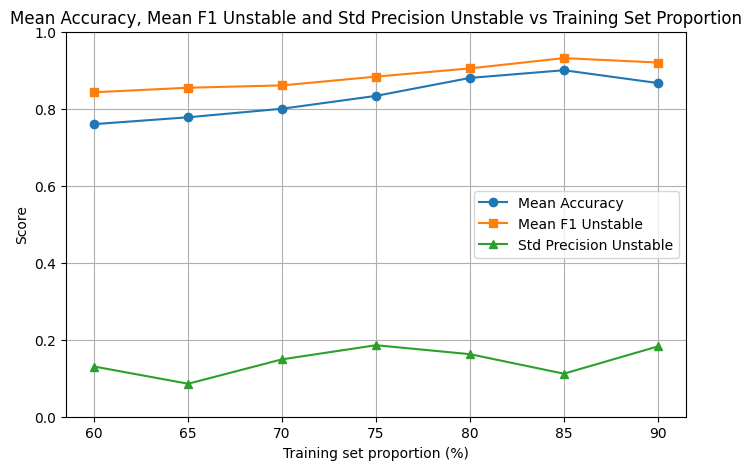

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output/lr_train_size_cv_summary.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

#### 折线图---10次求平均

In [5]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 10

# unstable 判定阈值
threshold = 0.5

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output/lr_train_size_cv_summary_10.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output/lr_train_size_cv_all_fold_predictions_10.csv",
    index=False
)

print("\nSaved:")
print("./output/lr_train_size_cv_summary_10.csv")
print("./output/lr_train_size_cv_all_fold_predictions_10.csv")

X shape: (23, 40)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.9000, AUC = 1.0000, F1 = 0.9333
Confusion matrix:
[[2 1]
 [0 7]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.7143, F1 = 0.8000
Confusion matrix:
[[1 2]
 [1 6]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.9048, F1 = 0.7692
Confusion matrix:
[[2 1]
 [2 5]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 1.0000, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.9048, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 6
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.7143, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 7
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.5714, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 8
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.7619, F1 = 0.8000
Confusion matr

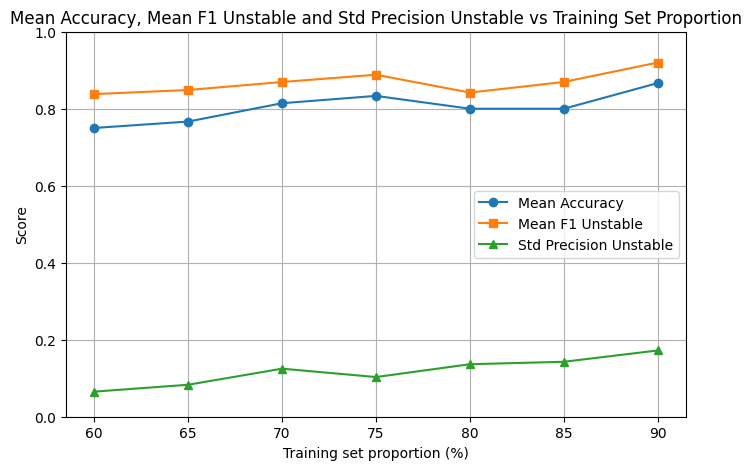

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output/lr_train_size_cv_summary_10.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()

#### 折线图----100次求平均

In [7]:
#####折线图----不同比例的数据来训练
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. 读取有标签数据
# =========================
X = pd.read_csv("./output/X_combined_basic_plus_pseudobulk.csv", index_col=0)
y = pd.read_csv("./output/y_sample_label_numeric.csv", index_col=0).iloc[:, 0]

# 确保 X 和 y 样本顺序一致
X = X.loc[y.index]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

# =========================
# 2. 设置训练比例和交叉验证次数
# =========================
train_sizes = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

# 你可以改成 5 或 10
n_splits = 100

# unstable 判定阈值
threshold = 0.5

random_state = 42

summary_rows = []
all_fold_predictions = []

# =========================
# 3. 对每个训练比例做交叉验证
# =========================
for train_size in train_sizes:
    test_size = 1 - train_size

    print("\n" + "=" * 80)
    print(f"Training size = {int(train_size * 100)}%, Holdout size = {int(test_size * 100)}%")
    print("=" * 80)

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        train_size=train_size,
        test_size=test_size,
        random_state=random_state
    )

    fold_metrics = []

    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =========================
        # 4. 建模
        # =========================
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                max_iter=1000,
                random_state=random_state
            ))
        ])

        model.fit(X_train, y_train)

        # =========================
        # 5. 预测剩余有标签数据
        # =========================
        prob_unstable = model.predict_proba(X_test)[:, 1]

        y_pred = (prob_unstable >= threshold).astype(int)

        # =========================
        # 6. 计算指标
        # =========================
        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, prob_unstable)
        else:
            auc = np.nan

        fold_metrics.append({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "accuracy": acc,
            "precision_unstable": precision,
            "recall_unstable": recall,
            "f1_unstable": f1,
            "roc_auc": auc
        })

        # =========================
        # 7. 保存每折预测明细
        # =========================
        fold_pred_df = pd.DataFrame({
            "train_size": train_size,
            "train_percent": int(train_size * 100),
            "fold": fold_id,
            "sample_id": X_test.index,
            "true_label_numeric": y_test.values,
            "prob_unstable": prob_unstable,
            "pred_label_numeric": y_pred
        })

        fold_pred_df["true_label"] = fold_pred_df["true_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        fold_pred_df["pred_label"] = fold_pred_df["pred_label_numeric"].map({
            1: "unstable",
            0: "non-unstable"
        })

        def assign_3class(p):
            if p >= 0.8:
                return "high-confidence unstable"
            elif p >= 0.6:
                return "unstable-like"
            else:
                return "non-unstable"

        fold_pred_df["pred_3class"] = fold_pred_df["prob_unstable"].apply(assign_3class)

        all_fold_predictions.append(fold_pred_df)

        print(f"\nFold {fold_id}")
        print(f"n_train = {len(X_train)}, n_test = {len(X_test)}")
        print(f"Accuracy = {acc:.4f}, AUC = {auc:.4f}, F1 = {f1:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))

    # =========================
    # 8. 汇总该训练比例的平均表现
    # =========================
    fold_metrics_df = pd.DataFrame(fold_metrics)

    summary_rows.append({
        "train_size": train_size,
        "train_percent": int(train_size * 100),
        "n_splits": n_splits,

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "std_accuracy": fold_metrics_df["accuracy"].std(),

        "mean_precision_unstable": fold_metrics_df["precision_unstable"].mean(),
        "std_precision_unstable": fold_metrics_df["precision_unstable"].std(),

        "mean_recall_unstable": fold_metrics_df["recall_unstable"].mean(),
        "std_recall_unstable": fold_metrics_df["recall_unstable"].std(),

        "mean_f1_unstable": fold_metrics_df["f1_unstable"].mean(),
        "std_f1_unstable": fold_metrics_df["f1_unstable"].std(),

        "mean_roc_auc": fold_metrics_df["roc_auc"].mean(),
        "std_roc_auc": fold_metrics_df["roc_auc"].std()
    })

# =========================
# 9. 保存结果
# =========================
summary_df = pd.DataFrame(summary_rows)
all_predictions_df = pd.concat(all_fold_predictions, axis=0)

summary_df = summary_df.sort_values("train_size")

print("\n" + "=" * 80)
print("Cross-validation summary")
print("=" * 80)
print(summary_df)

summary_df.to_csv(
    "./output/lr_train_size_cv_summary_100.csv",
    index=False
)

all_predictions_df.to_csv(
    "./output/lr_train_size_cv_all_fold_predictions_100.csv",
    index=False
)

print("\nSaved:")
print("./output/lr_train_size_cv_summary_100.csv")
print("./output/lr_train_size_cv_all_fold_predictions_100.csv")

X shape: (23, 40)
y distribution:
label
1    16
0     7
Name: count, dtype: int64

Training size = 60%, Holdout size = 40%

Fold 1
n_train = 13, n_test = 10
Accuracy = 0.9000, AUC = 1.0000, F1 = 0.9333
Confusion matrix:
[[2 1]
 [0 7]]

Fold 2
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.7143, F1 = 0.8000
Confusion matrix:
[[1 2]
 [1 6]]

Fold 3
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.9048, F1 = 0.7692
Confusion matrix:
[[2 1]
 [2 5]]

Fold 4
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 1.0000, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 5
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.9048, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 6
n_train = 13, n_test = 10
Accuracy = 0.8000, AUC = 0.7143, F1 = 0.8750
Confusion matrix:
[[1 2]
 [0 7]]

Fold 7
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.5714, F1 = 0.8235
Confusion matrix:
[[0 3]
 [0 7]]

Fold 8
n_train = 13, n_test = 10
Accuracy = 0.7000, AUC = 0.7619, F1 = 0.8000
Confusion matr

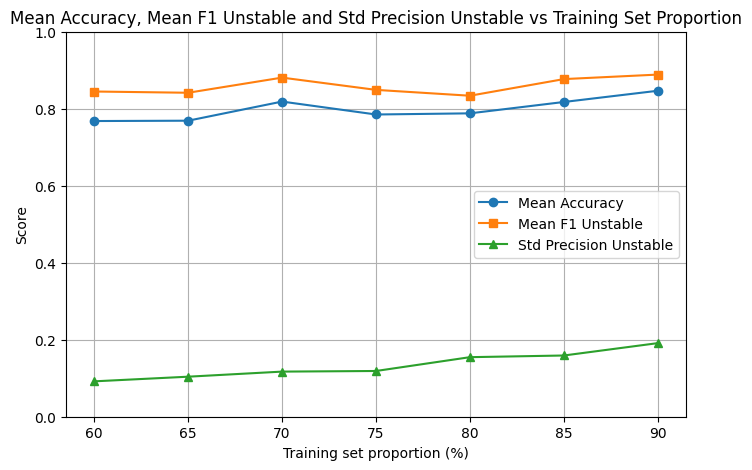

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取结果文件
df = pd.read_csv("./output/lr_train_size_cv_summary_100.csv")

# 去掉可能的空行
df = df.dropna(subset=[
    "train_percent",
    "mean_accuracy",
    "mean_f1_unstable",
    "std_precision_unstable"
])

# 按训练集比例排序
df = df.sort_values("train_percent")

# 画三折线图
plt.figure(figsize=(8, 5))

plt.plot(
    df["train_percent"],
    df["mean_accuracy"],
    marker="o",
    label="Mean Accuracy"
)

plt.plot(
    df["train_percent"],
    df["mean_f1_unstable"],
    marker="s",
    label="Mean F1 Unstable"
)

plt.plot(
    df["train_percent"],
    df["std_precision_unstable"],
    marker="^",
    label="Std Precision Unstable"
)

# 坐标轴和标题
plt.xlabel("Training set proportion (%)")
plt.ylabel("Score")
plt.title("Mean Accuracy, Mean F1 Unstable and Std Precision Unstable vs Training Set Proportion")

# x轴刻度
plt.xticks(df["train_percent"])

# y轴范围
plt.ylim(0, 1)

# 网格和图例
plt.grid(True)
plt.legend()

# 显示图像
plt.show()